In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report


In [ ]:
df=load_wine(as_frame=True).frame

df.sample(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
21,12.93,3.80,2.65,18.6,102.0,2.41,2.41,0.25,1.98,4.50,1.03,3.52,770.0,0
108,12.22,1.29,1.94,19.0,92.0,2.36,2.04,0.39,2.08,2.70,0.86,3.02,312.0,1
127,11.79,2.13,2.78,28.5,92.0,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466.0,1
123,13.05,5.80,2.13,21.5,86.0,2.62,2.65,0.30,2.01,2.60,0.73,3.10,380.0,1
88,11.64,2.06,2.46,21.6,84.0,1.95,1.69,0.48,1.35,2.80,1.00,2.75,680.0,1
164,13.78,2.76,2.30,22.0,90.0,1.35,0.68,0.41,1.03,9.58,0.70,1.68,615.0,2
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
17,13.83,1.57,2.62,20.0,115.0,2.95,3.40,0.40,1.72,6.60,1.13,2.57,1130.0,0
44,13.05,1.77,2.10,17.0,107.0,3.00,3.00,0.28,2.03,5.04,0.88,3.35,885.0,0
38,13.07,1.50,2.10,15.5,98.0,2.40,2.64,0.28,1.37,3.70,1.18,2.69,1020.0,0


In [ ]:
df.shape

(178, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target', ylabel='count'>

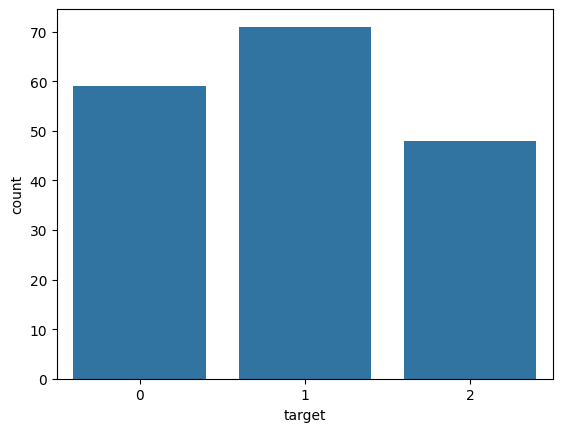

In [ ]:
sns.countplot(data= df , x='target')

In [ ]:
x=df.drop(['target'],axis=1)
y=df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
x_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


In [ ]:
y_train.nunique()


3

In [ ]:
knn_model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=15,  # akne neighbors ta fix koredilam
            metric='minkowski',
            p=2
        ))
    ]
)

In [ ]:
knn_model.fit(x_train,y_train) # akne dekho neighbors ta fix jeta dis setai ase


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=15))])

In [ ]:
y_pred=knn_model.predict(x_test)

y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)


1.0


In [ ]:
conf_metrics = confusion_matrix(y_test,y_pred)

conf_metrics


array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [ ]:
print(classification_report(y_test,y_pred)) # ata akta overall report show kortese
 # kmne model ta kaj kortese


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
#p=2

# ata molot kora karon jeno  k er binno binno man e kirom accuracy,recall,precisssion aitase seta measure kora
# k=(5,30)
performance=[]
accur=[]


for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),  # dekho n_neighboure k disi range er  modde measure kore dekanor jono
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2))
    ]
    )
  knn_model.fit(x_train,y_train)
  y_pred=knn_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  accur.append(acc)

  recall=recall_score(y_test,y_pred, average='weighted')
  precision=precision_score(y_test,y_pred, average='weighted')

  performance.append([k,acc,recall,precision])






In [ ]:

print(performance)

[[5, 0.9722222222222222, 0.9722222222222222, 0.9747474747474748], [6, 0.9722222222222222, 0.9722222222222222, 0.974074074074074], [7, 1.0, 1.0, 1.0], [8, 1.0, 1.0, 1.0], [9, 1.0, 1.0, 1.0], [10, 1.0, 1.0, 1.0], [11, 1.0, 1.0, 1.0], [12, 1.0, 1.0, 1.0], [13, 1.0, 1.0, 1.0], [14, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [15, 1.0, 1.0, 1.0], [16, 1.0, 1.0, 1.0], [17, 1.0, 1.0, 1.0], [18, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [19, 1.0, 1.0, 1.0], [20, 1.0, 1.0, 1.0], [21, 1.0, 1.0, 1.0], [22, 1.0, 1.0, 1.0], [23, 1.0, 1.0, 1.0], [24, 1.0, 1.0, 1.0], [25, 1.0, 1.0, 1.0], [26, 1.0, 1.0, 1.0], [27, 1.0, 1.0, 1.0], [28, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [29, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745]]


In [ ]:
print(accur)


[0.9722222222222222, 0.9722222222222222, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9722222222222222, 1.0, 1.0, 1.0, 0.9722222222222222, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9722222222222222, 0.9722222222222222]


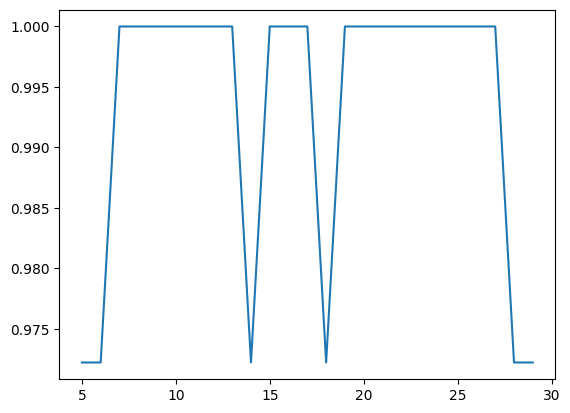

In [ ]:
plt.plot(range(5,30),accur)

In [ ]:
#p=1

performance=[]
accur=[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=1))
    ]
    )
  knn_model.fit(x_train,y_train)
  y_pred=knn_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  accur.append(acc)

  recall=recall_score(y_test,y_pred, average='weighted')
  precision=precision_score(y_test,y_pred, average='weighted')


  performance.append([k,acc,recall,precision])

In [ ]:

print(performance)


[[5, 1.0, 1.0, 1.0], [6, 1.0, 1.0, 1.0], [7, 1.0, 1.0, 1.0], [8, 1.0, 1.0, 1.0], [9, 1.0, 1.0, 1.0], [10, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [11, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [12, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [13, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [14, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [15, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [16, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [17, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [18, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [19, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [20, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [21, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [22, 0.9722222222222222, 0.9722222222222222, 0.9743589743589745], [23, 0.9722222222222222, 0.97222222222222

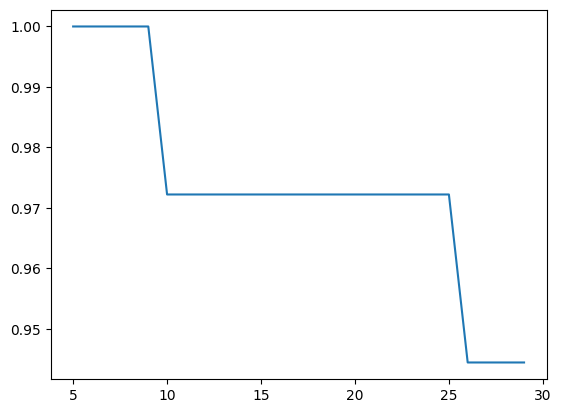

In [ ]:
plt.plot(range(5,30),accur)

KNN-এর সবচেয়ে গুরুত্বপূর্ণ parameter হলো:

```python
n_neighbors = 15
```

এর মানে হলো, নতুন কোনো data point এলে model তার **সবচেয়ে কাছের 15টি training sample** খুঁজবে।

ধরো তোমার training data এমন:

| Point | Class |
| ----- | ----- |
| A     | 0     |
| B     | 0     |
| C     | 1     |
| D     | 1     |
| E     | 1     |
| F     | 2     |
| ...   | ...   |

এখন একটি নতুন sample এসেছে:

```text
?
```

KNN প্রথমে এই sample থেকে সব training sample-এর distance বের করবে।

তারপর সবচেয়ে কাছের 15 জনকে বেছে নেবে।

ধরো ঐ 15 জনের class হলো:

```text
0,0,0,0,
1,1,1,1,1,1,
2,2,2,2,2
```

গণনা করলে:

```text
Class 0 = 4 জন
Class 1 = 6 জন
Class 2 = 5 জন
```

সবচেয়ে বেশি Class 1 আছে।

তাই prediction হবে:

```text
Class 1
```

---

### কেন k ছোট হলে সমস্যা?

ধরো:

```python
n_neighbors = 1
```

তাহলে শুধু সবচেয়ে কাছের ১ জনকে দেখবে।

যদি ওই ১ জন ভুল বা noise হয়, তাহলে prediction-ও ভুল হবে।

---

### কেন k খুব বড় হলেও সমস্যা?

ধরো:

```python
n_neighbors = 100
```

তখন অনেক দূরের sample-ও decision-এ ঢুকে যাবে।

ফলে local pattern হারিয়ে যেতে পারে।

---

### Wine Dataset-এর ক্ষেত্রে

তুমি loop চালিয়েছিলে:

```python
for k in range(5,30):
```

অর্থাৎ:

```text
k=5
k=6
k=7
...
k=29
```

এবং প্রতিটি k-এর accuracy বের করেছ।

কারণ আগে থেকে জানা নেই:

```text
k=5 ভালো?
k=10 ভালো?
k=15 ভালো?
k=25 ভালো?
```

যে k-তে accuracy সবচেয়ে বেশি হবে, সেটাই সাধারণত বেছে নেওয়া হয়।

---

সংক্ষেপে:

```python
n_neighbors = 15
```

মানে:

> নতুন sample-এর class predict করার সময় তার সবচেয়ে কাছের 15টি training sample-এর ভোট নেওয়া হবে, এবং যে class সবচেয়ে বেশি ভোট পাবে সেটাই prediction হবে।


অবশ্যই। এই কোডটা শুরু থেকে শেষ পর্যন্ত কী করছে সেটা সহজ বাংলায় বুঝাই।

---

## Library Import

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
```

### `numpy`

Numerical calculation-এর জন্য।

উদাহরণ:

```python
np.array([1,2,3])
```

---

### `pandas`

Dataset table আকারে handle করার জন্য।

উদাহরণ:

```python
pd.DataFrame()
```

---

### `matplotlib.pyplot`

Graph আঁকার জন্য।

উদাহরণ:

```python
plt.plot()
```

---

### `seaborn`

সুন্দর visualization করার জন্য।

উদাহরণ:

```python
sns.heatmap()
```

---

## Train-Test Split

```python
from sklearn.model_selection import train_test_split
```

Dataset কে train ও test অংশে ভাগ করার জন্য।

---

## Data Scaling

```python
from sklearn.preprocessing import StandardScaler
```

Feature scaling করার জন্য।

Formula:

[
z=\frac{x-\mu}{\sigma}
]

যাতে সব feature একই scale-এ আসে।

---

## Pipeline

```python
from sklearn.pipeline import Pipeline
```

একাধিক step একসাথে চালানোর জন্য।

যেমন:

```text
Data
 ↓
Scaling
 ↓
KNN
 ↓
Prediction
```

---

## Dataset Load

```python
from sklearn.datasets import load_wine
```

Wine dataset আনার জন্য।

Dataset-এ ৩টি wine class আছে।

Target:

```python
0
1
2
```

---

## KNN Model

```python
from sklearn.neighbors import KNeighborsClassifier
```

K-Nearest Neighbors classifier।

নতুন data point-এর class বের করে তার আশেপাশের neighbor দেখে।

---

## Evaluation Metrics

```python
from sklearn.metrics import accuracy_score,precision_score,recall_score
```

Model কত ভালো কাজ করছে তা মাপার জন্য।

---

### Accuracy

[
\frac{Correct}{Total}
]

---

### Precision

[
\frac{TP}{TP+FP}
]

---

### Recall

[
\frac{TP}{TP+FN}
]

---

## Extra Metrics

```python
from sklearn.metrics import confusion_matrix, classification_report
```

### Confusion Matrix

কে কোথায় ভুল করেছে দেখায়।

---

### Classification Report

একসাথে Accuracy, Precision, Recall, F1-score দেখায়।

---

# Dataset Load

```python
df = load_wine(as_frame=True).frame
```

Wine dataset DataFrame আকারে load করছে।

উদাহরণ:

| alcohol | malic_acid | ... | target |
| ------- | ---------- | --- | ------ |
| 14.23   | 1.71       | ... | 0      |

---

# Random Sample

```python
df.sample(10)
```

Dataset থেকে random 10 row দেখাবে।

শুধু dataset দেখার জন্য।

Training-এর কাজে লাগে না।

---

# Feature এবং Target আলাদা

```python
x = df.drop(['target'], axis=1)
```

Feature columns রাখছে।

---

```python
y = df['target']
```

Target column রাখছে।

---

ধরো:

| alcohol | color | target |
| ------- | ----- | ------ |
| 12.5    | 3.2   | 0      |

তাহলে

```python
x
```

হবে

| alcohol | color |
| ------- | ----- |
| 12.5    | 3.2   |

এবং

```python
y
```

হবে

```python
0
```

---

# Train Test Split

```python
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

---

### `test_size=0.2`

২০% test data।

৮০% training data।

Wine dataset-এ 178 sample থাকলে:

```text
Train ≈ 142
Test ≈ 36
```

---

### `random_state=42`

প্রতিবার একই split পাওয়ার জন্য।

Reproducibility।

---

### `stratify=y`

সব class-এর proportion বজায় রাখে।

ধরো:

```text
Class 0 = 40%
Class 1 = 35%
Class 2 = 25%
```

Train ও Test দুটিতেই এই ratio বজায় থাকবে।

---

# Pipeline

```python
knn_model = Pipeline(
```

একটি workflow তৈরি হচ্ছে।

---

## Step 1

```python
('scaler', StandardScaler())
```

Data scaling।

---

## Step 2

```python
('knn',
 KNeighborsClassifier(
     n_neighbors=15,
     metric='minkowski',
     p=2
 ))
```

KNN classifier।

---

### `n_neighbors=15`

সবচেয়ে কাছের 15 জন neighbor দেখবে।

---

### `metric='minkowski'`

Distance measure।

Minkowski distance-এর general formula:

[
\left(\sum |x_i-y_i|^p\right)^{1/p}
]

---

### `p=2`

Euclidean Distance।

[
\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}
]

এটাই সাধারণ "সোজা লাইনের" distance।

---

## Pipeline-এর Flow

```text
x_train
   ↓
StandardScaler
   ↓
Scaled Data
   ↓
KNN(k=15)
   ↓
Model Ready
```

তারপর:

```python
knn_model.fit(x_train,y_train)
```

Training

এবং

```python
y_pred = knn_model.predict(x_test)
```

Prediction।

---

তোমার কোডের মূল উদ্দেশ্য হলো:

**Wine dataset-এর উপর KNN classifier ব্যবহার করা, যেখানে প্রথমে data scaling করা হচ্ছে, তারপর Euclidean distance (p=2) ব্যবহার করে 15 nearest neighbors দেখে wine-এর class predict করা হচ্ছে।**


অবশ্যই। তোমার কোডটা লাইন ধরে ব্যাখ্যা করি।

```python
performance=[]
accur=[]
```

### 1. `performance=[]`

এখানে সব result একসাথে জমা রাখবে।

পরে এরকম হবে:

```python
[
 [5,0.94,0.94,0.95],
 [6,0.96,0.96,0.96],
 [7,0.97,0.97,0.97]
]
```

অর্থাৎ প্রতিটি k-এর জন্য Accuracy, Recall, Precision সংরক্ষণ করা হচ্ছে।

---

### 2. `accur=[]`

শুধুমাত্র Accuracy গুলো আলাদা করে রাখার জন্য।

যেমন:

```python
[0.94,0.96,0.97,0.95,...]
```

পরে graph আঁকার জন্য কাজে লাগে।

---

```python
for k in range(5,30):
```

### 3. `range(5,30)`

k = 5 থেকে k = 29 পর্যন্ত KNN চালাবে।

মানে:

```python
5,6,7,8,...,29
```

কারণ KNN-এ k-এর মান performance-এর উপর প্রভাব ফেলে।

তাই কোন k সবচেয়ে ভালো তা খুঁজে বের করছি।

---

```python
knn_model = Pipeline(
```

### 4. `Pipeline`

একাধিক step একসাথে চালানোর জন্য।

এখানে ২টা step আছে:

1. Data Scaling
2. KNN Classification

---

```python
('scaler', StandardScaler())
```

### 5. `StandardScaler()`

Data standardization করে।

Formula:

[
z = \frac{x-\mu}{\sigma}
]

উদাহরণ:

Feature A:

```python
Age = 20-50
```

Feature B:

```python
Income = 10000-1000000
```

Income-এর scale অনেক বড়।

Scaling না করলে KNN income-কে বেশি গুরুত্ব দিবে।

তাই সব feature একই scale-এ আনা হয়।

---

```python
('model', KNeighborsClassifier(...))
```

### 6. `KNeighborsClassifier`

KNN algorithm।

নতুন sample-এর class নির্ধারণ করে তার আশেপাশের প্রতিবেশীদের (neighbors) দেখে।

---

```python
n_neighbors=k
```

### 7. `n_neighbors`

কতজন neighbor দেখবে।

উদাহরণ:

```python
k=5
```

তাহলে সবচেয়ে কাছের 5 জনকে দেখে decision নিবে।

---

```python
metric='minkowski'
```

### 8. `metric='minkowski'`

Distance measure করার method।

KNN distance হিসাব করে nearest neighbor খুঁজে।

---

```python
p=1
```

### 9. `p=1`

Minkowski distance-এর parameter।

#### p=1

Manhattan Distance

[
|x_1-x_2| + |y_1-y_2|
]

Grid রাস্তা ধরে যাওয়ার মতো।

---

#### p=2

Euclidean Distance

[
\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}
]

সোজা লাইনে distance।

---

```python
knn_model.fit(x_train,y_train)
```

### 10. `fit()`

Training।

KNN-এর ক্ষেত্রে মূলত training data store করে রাখে।

---

```python
y_pred=knn_model.predict(x_test)
```

### 11. `predict()`

Test data-এর class predict করে।

উদাহরণ:

```python
[0,1,2,1,0]
```

---

```python
acc=accuracy_score(y_test,y_pred)
```

### 12. Accuracy

Formula:

[
Accuracy=\frac{Correct\ Predictions}{Total\ Predictions}
]

উদাহরণ:

100 টার মধ্যে 95 টা ঠিক

```python
Accuracy = 95%
```

---

```python
accur.append(acc)
```

### 13. `append()`

Accuracy list-এ যোগ করছে।

যেমন:

```python
accur=[0.94,0.96,0.97]
```

---

```python
recall=recall_score(...)
```

### 14. Recall

প্রকৃত positive-এর মধ্যে কতগুলো ধরতে পেরেছে।

Formula:

[
Recall=\frac{TP}{TP+FN}
]

উচ্চ Recall মানে কম miss করেছে।

---

```python
precision=precision_score(...)
```

### 15. Precision

যেগুলো positive বলেছে তার মধ্যে কতগুলো সত্যি positive।

Formula:

[
Precision=\frac{TP}{TP+FP}
]

উচ্চ Precision মানে কম ভুল positive prediction।

---

```python
average='weighted'
```

### 16. কেন `weighted`?

Wine dataset-এ 3টা class আছে:

```python
0
1
2
```

Precision/Recall বের করার সময় সব class-এর score combine করতে হয়।

`weighted` প্রতিটি class-এর sample সংখ্যা অনুযায়ী weight দেয়।

---

```python
performance.append([k,acc,recall,precision])
```

### 17. কেন?

প্রতিটি k-এর result store করার জন্য।

উদাহরণ:

```python
[
 [5,0.94,0.94,0.95],
 [6,0.96,0.96,0.96],
 [7,0.97,0.97,0.97]
]
```

পরে DataFrame বানিয়ে analysis করা যায়।

---

সংক্ষেপে পুরো কোডের লক্ষ্য:

**k=5 থেকে k=29 পর্যন্ত KNN চালিয়ে কোন k-তে Accuracy, Recall, Precision সবচেয়ে ভালো আসে সেটা খুঁজে বের করা।**
